In [9]:
import random

In [10]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [11]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [12]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()
     

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.924924,1.423302,-1.195170,-1.671530,-0.771729,1
1,0.747242,1.361057,-0.744414,-1.672009,-1.267208,1
2,0.245157,-1.239844,-0.913409,4.421885,1.986783,0
3,-1.955035,-0.020653,-0.951970,0.084468,0.943870,0
4,3.801477,1.412804,-0.981026,-0.118453,-2.072229,1


In [13]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [14]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [15]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [16]:
df1 = combined_sampling(df,0.5,0.5)

/var/folders/7m/jg_ng8n93vv88rkr5mm3mpsc0000gn/T/ipykernel_33715/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [17]:
df2 = combined_sampling(df,0.5,0.5)


/var/folders/7m/jg_ng8n93vv88rkr5mm3mpsc0000gn/T/ipykernel_33715/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [18]:
df3=combined_sampling(df,0.5,0.5)

/var/folders/7m/jg_ng8n93vv88rkr5mm3mpsc0000gn/T/ipykernel_33715/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [19]:
print(df1.columns)

Index(['col5', 'col1', 'target'], dtype='object')


In [20]:
print(df2.columns)

Index(['col2', 'col5', 'target'], dtype='object')


In [21]:
print(df3.columns)

Index(['col5', 'col3', 'target'], dtype='object')


In [22]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [24]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [25]:
from sklearn.tree import plot_tree

[Text(0.4117647058823529, 0.9166666666666666, 'x[1] <= 0.217\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.17647058823529413, 0.75, 'x[1] <= -1.274\ngini = 0.269\nsamples = 25\nvalue = [21, 4]'),
 Text(0.29411764705882354, 0.8333333333333333, 'True  '),
 Text(0.11764705882352941, 0.5833333333333334, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.23529411764705882, 0.5833333333333334, 'x[1] <= -0.67\ngini = 0.426\nsamples = 13\nvalue = [9, 4]'),
 Text(0.11764705882352941, 0.4166666666666667, 'x[0] <= 0.48\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.058823529411764705, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.17647058823529413, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.35294117647058826, 0.4166666666666667, 'x[1] <= 0.103\ngini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.29411764705882354, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.4117647058823529, 0.25, 'x[0] <= -0.898\ngini = 0.444\nsamples = 3\nvalue = [2, 

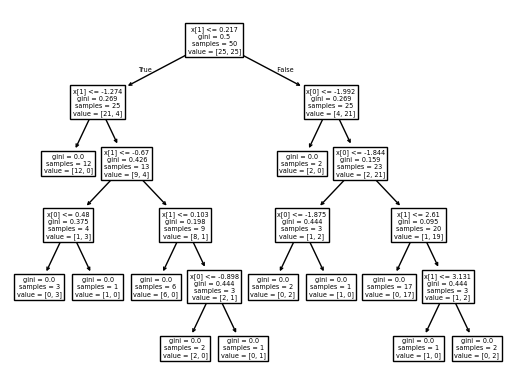

In [26]:
plot_tree(clf1)

[Text(0.5, 0.9, 'x[0] <= 0.65\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.3333333333333333, 0.7, 'x[0] <= -0.39\ngini = 0.285\nsamples = 29\nvalue = [24, 5]'),
 Text(0.41666666666666663, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.5, 0.5, 'x[0] <= -0.068\ngini = 0.486\nsamples = 12\nvalue = [7, 5]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.6666666666666666, 0.3, 'x[1] <= -1.34\ngini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8333333333333334, 0.1, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.6666666666666666, 0.7, 'gini = 0.0\nsamples = 21\nvalue = [0, 21]'),
 Text(0.5833333333333333, 0.8, '  False')]

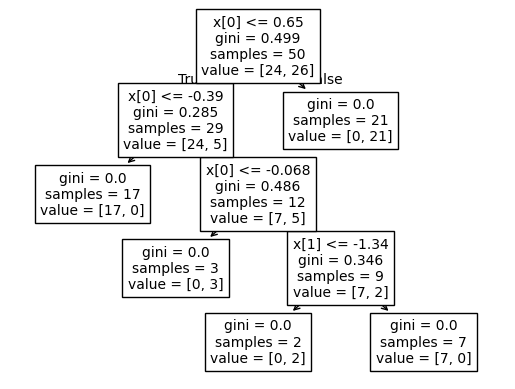

In [27]:
plot_tree(clf2)

[Text(0.5, 0.9, 'x[1] <= 0.232\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.3, 0.7, 'x[0] <= 0.429\ngini = 0.4\nsamples = 29\nvalue = [8, 21]'),
 Text(0.4, 0.8, 'True  '),
 Text(0.2, 0.5, 'x[0] <= -0.824\ngini = 0.219\nsamples = 24\nvalue = [3, 21]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 17\nvalue = [0, 17]'),
 Text(0.3, 0.3, 'x[1] <= -0.754\ngini = 0.49\nsamples = 7\nvalue = [3, 4]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.4, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.7, 0.7, 'x[0] <= -1.41\ngini = 0.172\nsamples = 21\nvalue = [19, 2]'),
 Text(0.6, 0.8, '  False'),
 Text(0.6, 0.5, 'gini = 0.0\nsamples = 13\nvalue = [13, 0]'),
 Text(0.8, 0.5, 'x[0] <= -0.775\ngini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.7, 0.3, 'x[1] <= 1.325\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamp

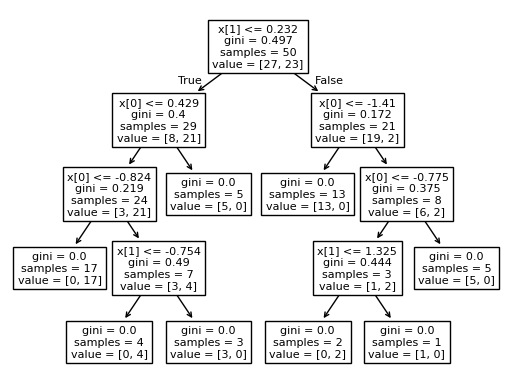

In [28]:
plot_tree(clf3)

In [30]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))


/Users/aavarttyagi/ml_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [31]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))


/Users/aavarttyagi/ml_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [32]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/Users/aavarttyagi/ml_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [33]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
17,0.664715,1.909888,-0.826649,-1.752096,-1.349468,1
67,2.570893,0.692242,-0.539664,-0.584068,-1.263730,1
39,-1.686537,-1.677319,2.798551,0.562529,-2.586600,0
4,3.801477,1.412804,-0.981026,-0.118453,-2.072229,1
8,1.430998,0.073558,-1.640561,-2.087068,-0.350593,1
18,1.493024,2.032665,-0.152201,0.754230,-2.080537,1
0,0.924924,1.423302,-1.195170,-1.671530,-0.771729,1
93,-3.749038,-0.505031,-0.575334,-1.738992,1.339123,0
98,-1.117951,-2.526204,3.715725,1.468409,-2.700665,0
4,3.801477,1.412804,-0.981026,-0.118453,-2.072229,1
